<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Read World bank CSV

In [3]:
df = pd.read_csv('WorldBank.csv')

In [4]:
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.258806,19.573943,22.081252,21.585397,22.301808,21.566095,22.178186,26.659006,31.226330,37.451067,42.400653,41.828912,46.313884,50.901265,59.042504,72.275852,78.116203,82.606603,78.899368,84.160663,100.000000,102.316461,116.212396,139.131368,180.863299,235.058153,287.422633,354.320624,459.725149,389.125587,534.108397,714.748450,700.408454,742.928128,761.441742,632.269428,624.224980,706.102795,766.360840,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.891155,2.524270,2.254364,1.939747,1.701099,1.292772,1.428902,1.355298,1.303746,1.379080,1.287503,1.456077,1.618537,1.919413,2.676314,2.674903,2.173806,3.067917,2.807954,2.409288,2.516342,2.924316,2.563870,2.079279,1.699160,3.324636,3.500758,4.863602,3.276929,3.133998,4.019403,5.017154,5.664129,5.537929,5.548620,6.531495,6.403614,5.246771,5.729495,5.060904,4.706801,4.471147,3.760466,3.921611,3.438072,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.48805,10.124611,9.451370,10.529480,10.891125,11.150566,9.806930,12.215451,18.456246,12.775461,9.385080,11.830757,10.452502,15.621482,10.719374,8.129319,10.823187,12.570897,14.386597,12.746613,14.295140,12.942283,16.183956,16.420075,15.549096,11.379097,14.598510,14.318517,15.476213,15.286289,21.121521,8.413243,9.137741,4.818722,10.382430,4.778729,0.220435,0.165789,0.134654,23.401602,27.898545,28.664795,27.082613,27.887094,29.315590,6.640615,0.706942,0.615325,0.473067,0.547571,0.755066,0.273842,0.440954,1.514439,2.228351,2.270593,1.770314,0.535419,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,17.080013,15.197912,16.863038,22.008132,34.149020,32.085619,25.044544,23.303043,20.924141,14.583768,9.595939,20.072490,19.687630,31.845541,27.480790,16.434690,13.846910,8.918821,8.986222,8.540796,NaN,11.658849,10.179991,8.414073,7.041373,8.439772,8.049490,3.509296,3.238412,2.699533,3.815987,3.126319,6.032388,4.307798,4.711904,5.621811,8.934855,7.229270,4.662568,5.810032,5.893396,5.911480,4.731834,3.670243,3.042742,3.420520,2.492372,4.211723,3.951092,3.741041,4.048246,3.895215,4.458509,5.758038,6.505293,6.137617,4.156488,4.248261,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.575820,NaN,94.223980,NaN,NaN,NaN,93.968380,93.784490,NaN,92.995480,90.017780,92.166000,90.355920,90.339940,92.561180,13.922990,11.451460,14.421590,8.845916,8.005064,6.980305,8.434346,8.641136,8.576307,NaN,5.802677,7.707811,8.288774,9.111423,NaN,NaN


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.147485e+02,7.004085e+02,7.429281e+02,7.614417e+02,6.322694e+02,6.242250e+02,7.061028e+02,7.663608e+02,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614e+00,5.246771e+00,5.729495e+00,5.060904e+00,4.706801e+00,4.471147e+00,3.760466e+00,3.921611e+00,3.438072e+00,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.488050e+00,1.012461e+01,9.451370e+00,1.052948e+01,1.089112e+01,...,7.550664e-01,2.738416e-01,4.409538e-01,1.514439e+00,2.228351e+00,2.270593e+00,1.770314e+00,5.354193e-01,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,1.708001e+01,1.519791e+01,1.686304e+01,2.200813e+01,...,3.741041e+00,4.048246e+00,3.895215e+00,4.458509e+00,5.758038e+00,6.505293e+00,6.137617e+00,4.156488e+00,4.248261e+00,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346e+00,8.641136e+00,8.576307e+00,NaN,5.802677e+00,7.707811e+00,8.288774e+00,9.111423e+00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,India,IND,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.002065e+00,1.312934e+00,1.516276e+00,1.695659e+00,2.092116e+00,1.937363e+00,1.506588e+00,1.552336e+00,1.760283e+00,NaN
1436,India,IND,"Net capital account (BoP, current US$)",BN.TRF.KOGT.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,6.791581e+07,-5.972328e+08,9.618297e+08,-7.433364e+07,3.706943e+07,1.368359e+08,3.731153e+07,-1.231007e+08,-1.155591e+09,NaN
1437,India,IND,"Travel services (% of service imports, BoP)",BM.GSR.TRVL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.761773e+01,1.544257e+01,1.475397e+01,1.799216e+01,1.795378e+01,1.707263e+01,1.686302e+01,1.716750e+01,1.755462e+01,NaN
1438,India,IND,Cereal production (metric tons),AG.PRD.CREL.MT,NaN,8.737650e+07,8.725755e+07,9.037301e+07,9.370600e+07,7.969950e+07,...,2.878600e+08,2.932900e+08,2.949095e+08,2.960100e+08,2.843330e+08,2.978500e+08,3.136100e+08,NaN,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [9]:
data = df[df['Indicator Name'] == 'Population ages 15-64 (% of total population)']

data.head()
india = data[data['Country Name'] == 'India']

india

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,55.090901,55.155347,55.345073,55.570144,55.781947,55.856768,55.952682,56.072472,56.234476,56.444053,56.497226,56.620685,56.789002,56.969144,57.142558,57.181055,57.226308,57.28875,57.390544,57.541421,57.55351,57.654512,57.818753,58.015012,58.229902,58.374038,58.54727,58.75605,59.012126,59.316577,59.565073,59.85723,60.186001,60.539715,60.90862,61.188987,61.499385,61.830845,62.173897,62.522765,62.80843,63.10261,63.409248,63.741967,64.108211,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [10]:
X = india.columns[4:].astype(int).values.reshape(-1,1)

y = india.iloc[0,4:].values

In [12]:
X

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019],
       [2020]])

In [13]:
y

array([np.float64(56.49748004), np.float64(56.17753236),
       np.float64(55.80745463), np.float64(55.46166361),
       np.float64(55.24893881), np.float64(55.21135053),
       np.float64(55.09090078), np.float64(55.15534672),
       np.float64(55.34507283), np.float64(55.57014408),
       np.float64(55.78194745), np.float64(55.85676846),
       np.float64(55.95268174), np.float64(56.07247186),
       np.float64(56.23447551), np.float64(56.44405309),
       np.float64(56.49722595), np.float64(56.62068516),
       np.float64(56.78900152), np.float64(56.9691436),
       np.float64(57.1425581), np.float64(57.18105454),
       np.float64(57.22630775), np.float64(57.28875038),
       np.float64(57.39054366), np.float64(57.54142108),
       np.float64(57.55350984), np.float64(57.6545119),
       np.float64(57.81875323), np.float64(58.01501187),
       np.float64(58.22990246), np.float64(58.37403848),
       np.float64(58.5472698), np.float64(58.75605047),
       np.float64(59.012126), np.fl

array([[56.49748004],
       [56.17753236],
       [55.80745463],
       [55.46166361],
       [55.24893881],
       [55.21135053],
       [55.09090078],
       [55.15534672],
       [55.34507283],
       [55.57014408],
       [55.78194745],
       [55.85676846],
       [55.95268174],
       [56.07247186],
       [56.23447551],
       [56.44405309],
       [56.49722595],
       [56.62068516],
       [56.78900152],
       [56.9691436],
       [57.1425581],
       [57.18105454],
       [57.22630775],
       [57.28875038],
       [57.39054366],
       [57.54142108],
       [57.55350984],
       [57.6545119],
       [57.81875323],
       [58.01501187],
       [58.22990246],
       [58.37403848],
       [58.5472698],
       [58.75605047],
       [59.012126],
       [59.31657719],
       [59.56507329],
       [59.8572303],
       [60.18600058],
       [60.53971518],
       [60.90862046],
       [61.18898716],
       [61.4993847],
       [61.83084479],
       [62.173897],
       [62.52276485]

# Plot scatter plot of Population ages 15-64 (% of total population)

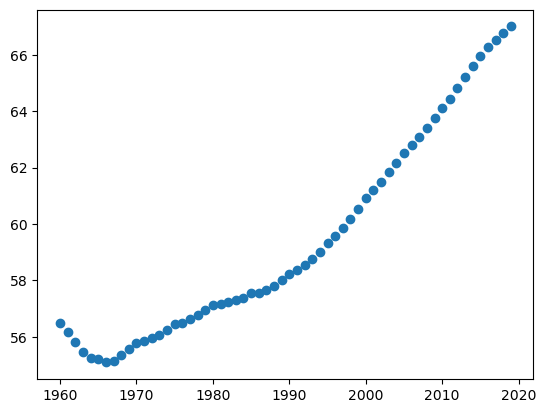

In [11]:
plt.scatter(X,y)

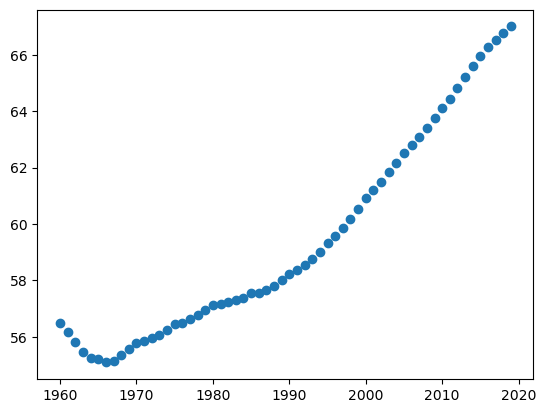

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [15]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

y_train = sc_y.fit_transform(y_train.reshape(-1,1))

Scaling Complete.


# Splitting the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

# Fitting SVR on 3 Different Kernel on dataset

In [16]:
svr_linear = SVR(kernel='linear')

svr_linear.fit(X_train,y_train.ravel())

SVR(kernel='linear')

In [17]:
svr_poly = SVR(kernel='poly',degree=3)

svr_poly.fit(X_train,y_train.ravel())

SVR(kernel='poly')

In [18]:
svr_rbf = SVR(kernel='rbf')

svr_rbf.fit(X_train,y_train.ravel())

SVR()

# Predict the x_test using 3 Kernel

In [25]:
y_pred_linear = svr_linear.predict(X_test)

In [26]:
y_pred_poly = svr_poly.predict(X_test)

In [27]:
y_pred_rbf = svr_rbf.predict(X_test)

# Visualising the  results

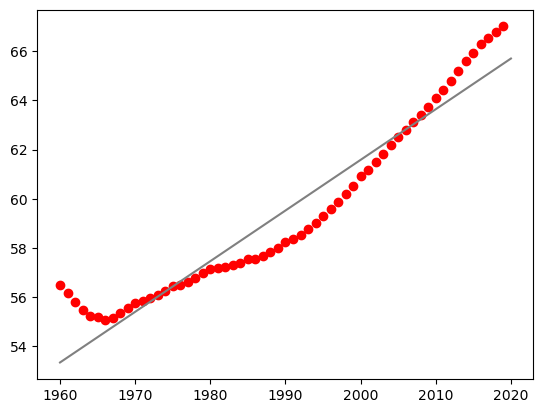

In [28]:
plt.scatter(X, y, color='red', label='Actual Date')

plt.plot(X,sc_y.inverse_transform(svr_linear.predict(sc_X.transform(X)).reshape(-1,1)),color='grey',label='linear Kernel')

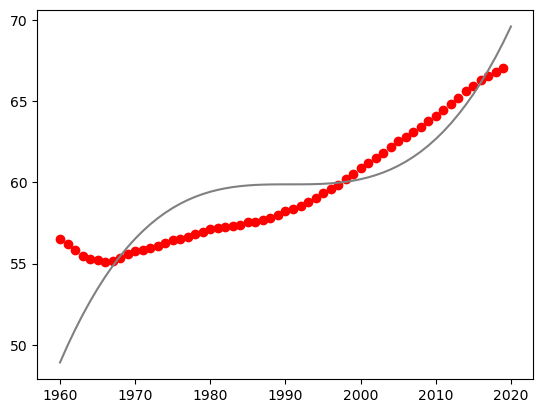

In [29]:
plt.scatter(X, y, color='red', label='Actual Date')

plt.plot(X,sc_y.inverse_transform(svr_poly.predict(sc_X.transform(X)).reshape(-1,1)),color='grey',label='poly Kernel')

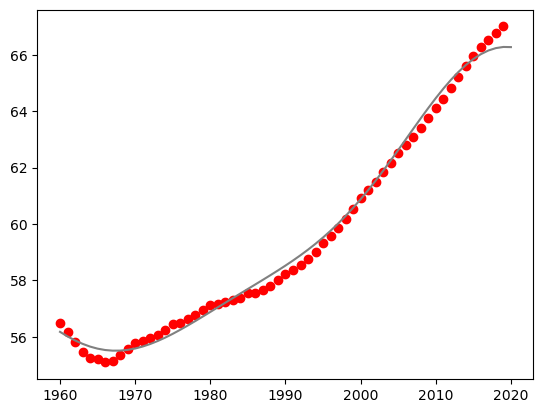

In [30]:
plt.scatter(X, y, color='red', label='Actual Date')

plt.plot(X,sc_y.inverse_transform(svr_rbf.predict(sc_X.transform(X)).reshape(-1,1)),color='grey',label='rbf Kernel')

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

The predicted value for input 2025 is: 66.47
